In [ ]:
import numpy as np
import pandas as pd

df_train = pd.read_parquet("data/processed/train.parquet")
X_train = df_train.drop(columns=["target"]).copy()
y_train = df_train["target"].copy()

term_months = df_train["term"].str.extract(r"(\d+)").astype(int).iloc[:, 0]

fn_cost = np.where(y_train == 1, df_train["funded_amnt"], 0)
fp_cost = np.where(
    y_train == 0, df_train["installment"] * term_months - df_train["funded_amnt"], 0
)

costs = pd.DataFrame({"fn_cost": fn_cost, "fp_cost": fp_cost}, index=df_train.index)
print(costs.head())

   fn_cost  fp_cost
0      0.0  1695.48
1      0.0   582.04
2      0.0   682.84
3      0.0   593.68
4      0.0   225.60


In [ ]:
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.preprocessing import get_features

numeric_features, categorical_features = get_features(df_train)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(max_iter=1000, class_weight="balanced", C=0.2158),
        ),
    ],
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
                max_depth=13,
                min_samples_leaf=8,
                n_estimators=288,
            ),
        ),
    ],
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LGBMClassifier(
                is_unbalance=True,
                random_state=42,
                verbose=-1,
                n_jobs=-1,
                learning_rate=0.0562,
                max_depth=9,
                n_estimators=363,
                num_leaves=61,
            ),
        ),
    ],
)

pipelines = {
    "logistic_regression": balanced_pipeline,
    "random_forest": random_forest_pipeline,
    "lightgbm_unbalanced": lgbm_pipeline,
}
tscv = TimeSeriesSplit(n_splits=3)

probabilities = {name: np.zeros(len(X_train)) for name in pipelines.keys()}
tested_mask = np.zeros(len(X_train), dtype=bool)

for train_idx, test_idx in tscv.split(X_train):
    tested_mask[test_idx] = True
    for name, pipeline in pipelines.items():
        pipeline_clone = clone(pipeline)
        pipeline_clone.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        proba = pipeline_clone.predict_proba(X_train.iloc[test_idx])[:, 1]
        probabilities[name][test_idx] = proba


In [18]:
thresholds = np.linspace(0, 1, 101)
results = []

y_eval = y_train[tested_mask]
costs_eval = costs[tested_mask]

for name, proba in probabilities.items():
    proba_eval = proba[tested_mask]
    for t in thresholds:
        predicted_reject = proba_eval >= t

        fn_mask = (y_eval == 1) & ~predicted_reject
        fp_mask = (y_eval == 0) & predicted_reject

        total_cost = (
            costs_eval.fn_cost[fn_mask].sum() + costs_eval.fp_cost[fp_mask].sum()
        )
        results.append({"model": name, "threshold": t, "total_cost": total_cost})

results_df = pd.DataFrame(results)

best_idx = results_df.groupby("model")["total_cost"].idxmin()

print(f"Cost of rejecting all applicants: ${costs_eval.fp_cost.sum():,.2f}")
print(f"Cost of approving all applicants: ${costs_eval.fn_cost.sum():,.2f}")

for name, idx in best_idx.items():
    min_cost_row = results_df.loc[idx]
    print(
        f"Model: {name}, Optimal Threshold: {min_cost_row.threshold:.2f}, Minimum Total Cost: ${min_cost_row.total_cost:,.2f}"
    )


Cost of rejecting all applicants: $2,318,804,304.08
Cost of approving all applicants: $2,581,402,650.00
Model: lightgbm_unbalanced, Optimal Threshold: 0.50, Minimum Total Cost: $2,026,355,068.16
Model: logistic_regression, Optimal Threshold: 0.47, Minimum Total Cost: $2,056,132,466.80
Model: random_forest, Optimal Threshold: 0.48, Minimum Total Cost: $2,087,897,618.56


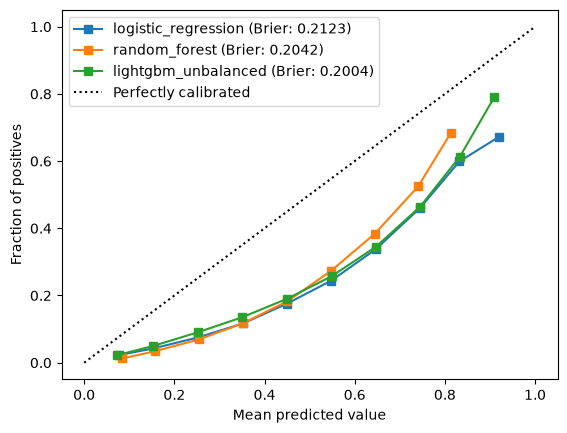

In [19]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

brier_results = {}

for model_name, proba in probabilities.items():
    proba_eval = proba[tested_mask]
    brier = brier_score_loss(y_eval, proba_eval)
    brier_results[model_name] = brier


calibration_results = {}

for model_name, proba in probabilities.items():
    proba_eval = proba[tested_mask]
    (fraction_of_positives, mean_predicted_value) = calibration_curve(
        y_eval, proba_eval, n_bins=10, strategy="uniform"
    )
    calibration_results[model_name] = (fraction_of_positives, mean_predicted_value)

for model_name, (
    fraction_of_positives,
    mean_predicted_value,
) in calibration_results.items():
    plt.plot(
        mean_predicted_value,
        fraction_of_positives,
        "s-",
        label=f"{model_name} (Brier: {brier_results[model_name]:.4f})",
    )

plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()


# Understanding Week 7

## Cost-Sensitive Thresholds

A 0.5 threshold assumes both mistakes cost the same. They don't. Missing a default (FN) loses the full funded_amnt. Rejecting a good loan (FP) only loses the interest margin we would have earned (installment \* term - funded_amnt). We built a cost matrix from these two costs and swept thresholds to find the one that actually minimizes total dollar cost, instead of just guessing 0.5.

One issue came up along the way. TimeSeriesSplit(n_splits=3) never puts the earliest 25% of loans into a test fold, so those rows never get a real out-of-fold prediction. Leaving them in the sweep would have added a fixed ~$620M of cost to every threshold, since a stuck-at-0 probability always counts as "approved". We fixed this by only scoring the 75% of rows that were actually tested.

| Model               | Optimal Threshold | Min Total Cost | vs. reject everyone | vs. approve everyone |
| ------------------- | ----------------- | -------------- | ------------------- | -------------------- |
| LightGBM            | 0.50              | $2.03B         | 12.6% lower         | 21.5% lower          |
| Logistic Regression | 0.47              | $2.06B         | 11.3% lower         | 20.3% lower          |
| Random Forest       | 0.48              | $2.09B         | 10.0% lower         | 19.1% lower          |

Rejecting everyone ($2.32B) actually beats approving everyone ($2.58B) as a baseline. In this data, missing a default costs more on average than losing a good loan's margin, so rejecting blindly isn't a bad guess. That makes reject-everyone the harder baseline to beat. LightGBM only beats it by 12.6%, not the nicer looking 21.5% you get comparing to approve-everyone.

## Calibration

Reliability curves show all three models are overconfident, worst at high predicted probabilities (Brier scores: LightGBM 0.2004, Random Forest 0.2042, Logistic Regression 0.2123). When a model says "90% chance of default", the real rate in that bucket is only 67-79%. This explains why every optimal threshold landed near 0.5 even though the true default rate is about 19.5%. class_weight="balanced" and is_unbalance=True rescale the probability axis during training, so 0.5 on a model's output doesn't mean 50% real odds. The threshold sweep still works fine, since it optimizes on dollar cost directly and doesn't need calibrated probabilities. But the threshold numbers themselves are model-specific cutoffs, not probabilities you could sanity check at face value.
